#  Customer Experience Differences Between To-Go and Sit-Down Specialty Coffee

## Table of contents
1. Project Overview
2. Import Libraries and insert datas
3. Checking values
4. To-Go vs Sit-Down review length and rating comparison
5. NLP Strategy Design
6. Data Validation
7. Understanding Negative Experiences
8. Understanding Positive Experiences
9. Comparing to-go vs sit-in
10. Final insights


# 0. Project Overview

### 0.1 Objectives
The goal of this project is to analyze customer experience differences 
between To-Go and Sit-Down specialty coffee shops using Google Reviews data.

The analysis aims to:
- identify behavioral differences in customer feedback
- understand what drives positive and negative experiences
- explore how review characteristics differ between café types

### 0.2 Research questions 
- Are there differences in average ratings between To-Go and Sit-Down cafés?    +
- What themes appear most frequently in reviews for each type?      +
- What factors are associated with negative reviews?    +
- Are Sit-Down café reviews more emotional than To-Go reviews?     +
- Are longer reviews correlated with lower ratings?    +

#    1. Import Libraries and insert datas

### 1.1 Importing libraries and inserting datas

In [2]:
import pandas as pd 
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib_inline as pllt
import seaborn as sns

In [3]:
data = pd.read_excel("data_cafenele.xlsx")

### 1.2 First look at data

In [4]:
data.shape

(400, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cafe_name    400 non-null    object 
 1   sit_down     400 non-null    object 
 2   cafe_type    400 non-null    object 
 3   rating       400 non-null    int64  
 4   review_text  400 non-null    object 
 5   mancare      400 non-null    int64  
 6   servire      400 non-null    int64  
 7   atmosfera    400 non-null    int64  
 8   review_date  0 non-null      float64
dtypes: float64(1), int64(4), object(4)
memory usage: 28.3+ KB


In [6]:
data.columns

Index(['cafe_name', 'sit_down', 'cafe_type', 'rating', 'review_text',
       'mancare', 'servire', 'atmosfera', 'review_date'],
      dtype='object')

#    2. Checking values

### 2.1 Check missing values & Replace Artificial Zeros with Missing Values

In [7]:
data[['mancare','servire','atmosfera']]=data[['mancare','servire','atmosfera']].replace(0,np.nan)

In [8]:
data.isna().sum()

cafe_name        0
sit_down         0
cafe_type        0
rating           0
review_text      0
mancare        104
servire         69
atmosfera       75
review_date    400
dtype: int64

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cafe_name    400 non-null    object 
 1   sit_down     400 non-null    object 
 2   cafe_type    400 non-null    object 
 3   rating       400 non-null    int64  
 4   review_text  400 non-null    object 
 5   mancare      296 non-null    float64
 6   servire      331 non-null    float64
 7   atmosfera    325 non-null    float64
 8   review_date  0 non-null      float64
dtypes: float64(4), int64(1), object(4)
memory usage: 28.3+ KB


#    3 Feauture Engineering

### 3.1 Create a lenght_review column

In [10]:
data['review_text'].astype(str).str.len()

0      176
1      111
2      193
3       65
4       35
      ... 
395    173
396     41
397     13
398     44
399     78
Name: review_text, Length: 400, dtype: int64

In [11]:
data['review_length'] = data['review_text'].astype(str).str.len()

### 3.2 Review lenght overview

In [12]:
data['review_length'].describe()

count     400.000000
mean      148.830000
std       175.669763
min         3.000000
25%        43.000000
50%        89.000000
75%       179.750000
max      1018.000000
Name: review_length, dtype: float64

Text(0.5, 0, 'Review_length')

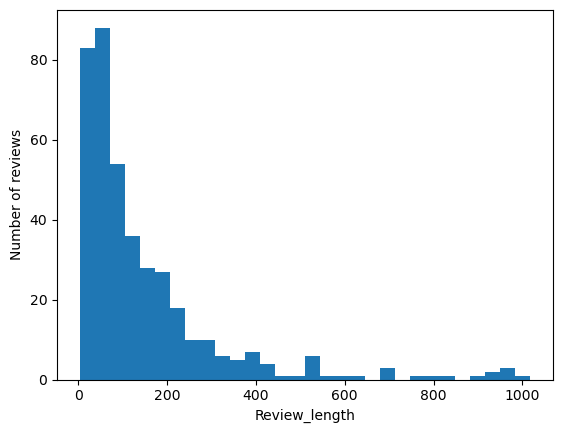

In [13]:
plt.hist(data['review_length'], bins=30)
plt.ylabel('Number of reviews')
plt.xlabel('Review_length')

### 3.3 Review length and rating correlation 

In [14]:
review_vs_rating = data.groupby('rating')['review_length'].mean()
review_vs_rating

rating
1    262.774194
2    209.000000
3    226.153846
4    137.363636
5    135.187683
Name: review_length, dtype: float64

<Axes: xlabel='rating', ylabel='review_length'>

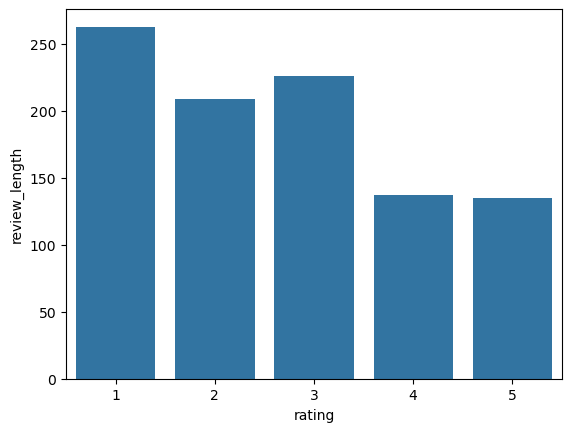

In [15]:
sns.barplot(review_vs_rating)

### Observation
Longer reviews tend to be associated with lower ratings. This pattern may occur because dissatisfied customers are more inclined to provide detailed explanations of their negative experiences, whereas satisfied customers typically leave shorter comments or simple positive feedback.

In [16]:
top10_cele_mai_lungi_reviews = data.sort_values('review_length', ascending=False)[['cafe_name','review_text','review_length','rating']].head(10)

In [17]:
top10_cele_mai_lungi_reviews

,cafe_name,review_text,review_length,rating
6,tucano coffee dorobanti,"Am fost recent la Tucano Caffè Romană și, din ...",1018,1
343,DODA5,"The coffee shop looks amazing, real aesthetic ...",978,5
330,DODA5,Am vizitat cafeneaua “DODA55” după ce am tot v...,966,5
259,Coffee Store,"Am mai fost in aceasta locatie, tocmai de acee...",952,1
325,DODA5,Am descoperit recent cafeneaua DODA5 5 la reco...,925,5
301,DODA5,O atitudine total nepotrivita si aroganta de l...,920,1
394,Roasted Coffee Shop Strada Batistei,tenție spanioli 🇪🇸\n\n Aspecte pozitive: Dacă ...,901,5
45,tucano coffee dorobanti,Atmosfera localul e foarte faina. Poți sta aco...,818,5
235,Van Fruct,Fără îndoială una dintre cele mai bune cafenel...,808,5
102,HotSpot Coffee,Am descoperit una dintre cele mai misto cafene...,767,5


#    4. To-Go vs Sit-Down review length and rating comparison 

Text(0.5, 1.0, 'Average rating')

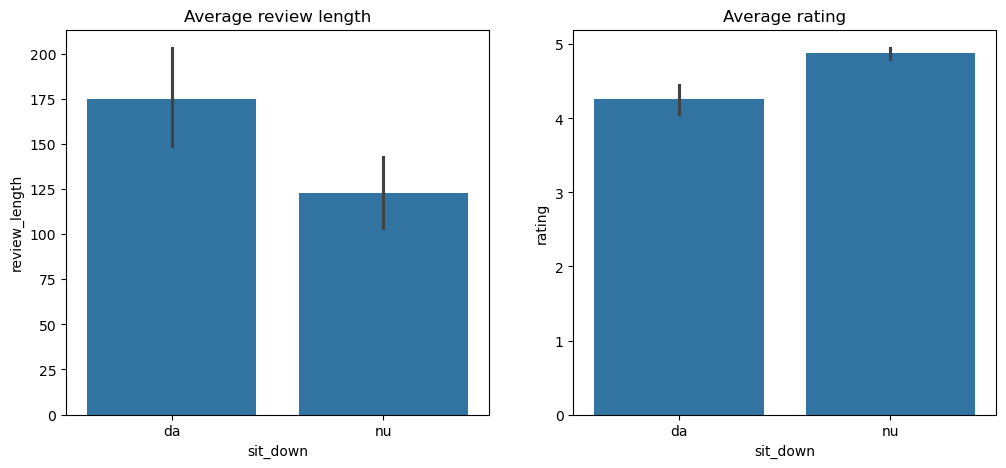

In [18]:
fig,axes = plt.subplots(1,2,figsize= (12,5))
sns.barplot(data , x = 'sit_down' , y = 'review_length', ax=axes[0])
sns.barplot(data , x = 'sit_down' , y = 'rating')
axes[0].set_title('Average review length')
axes[1].set_title('Average rating')

#    5. NLP Strategy Design

NLP Strategy Design
The goal of the NLP stage is to transform unstructured customer reviews 
into structured analytical features using the OpenAI API.

The following information will be extracted from each review:

- Sentiment (positive / neutral / negative)
- Main Topics discussed in the review
- Main Reason influencing customer experience
- One-sentence Review Summary

### 5.1 Openai setup

In [241]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [242]:
api_key= os.getenv('OPENAI_API_KEY')

In [30]:
!pip install -U openai

In [243]:
from openai import OpenAI
import json

### 5.2 API test

In [244]:
client = OpenAI(api_key=api_key)

response = client.responses.create(
    model = 'gpt-4.1-mini',
    input = 'Say hello Damian and confirm the API works'
)
print(response.output_text)


Hello Damian! The API is working perfectly. How can I assist you today?


In [35]:
sample_review = data['review_text'].iloc[0]
sample_review


'Perfect to go in the morning when there are only a few people there. Good quality, nice atmosphere, especially the interior design, and friendly staff. Really good, I recommend'


### 5.3 Prompt design and testing on sample reviews


In [36]:
prompt = f"""
Analyze the following coffee shop review.

Return ONLY a JSON object with this structure:

{{
"sentiment": "",
"topics": [],
"main_reason": "",
"summary": ""
}}

Review:
{sample_review}
"""

response = client.responses.create(
    model="gpt-4.1-mini",
    input=prompt
)

print(response.output_text)

```json
{
  "sentiment": "positive",
  "topics": ["quality", "atmosphere", "interior design", "staff", "recommendation"],
  "main_reason": "Good quality coffee, nice atmosphere with appealing interior design, and friendly staff",
  "summary": "A highly recommended coffee shop ideal for quiet mornings, praised for its quality, friendly staff, and appealing interior."
}
```


In [37]:
sample_reviews = data['review_text'].sample(5, random_state=42)
sample_reviews

209    Cafeaua de la vanfruct poate fi bautura pe car...
280            The best service and coffee in Bucharest!
33     Locatie frumoasa, plina de studenti, preturi m...
210    Probably the best cappuccino I’ve ever had! At...
93     Coffetea  Piața Romană este o oprire excelentă...
Name: review_text, dtype: object

In [38]:
ALLOWED_SENTIMENTS = [
    "positive",
    "negative",
    "mixed",
    "neutral"
]

In [39]:
ALLOWED_TOPICS = [
    "coffee_quality",
    "staff_behavior",
    "service_speed",
    "atmosphere",
    "location",
    "food",
    "price",
    "cleanliness",
    "noise_crowding"
]

In [40]:
def build_prompt(review_text:str):
    topics_list = ",".join(ALLOWED_TOPICS)
    sentiment_list = ",".join(ALLOWED_SENTIMENTS)
    return f"""
You are labeling customer reviews for a data analysis project.

Return ONLY a valid JSON object with exactly these keys:
{{
  "sentiment": "",
  "topics": [],
  "main_reason": "",
  "summary": ""
}}

Rules:
- sentiment must be one of: {sentiment_list}
- topics must be a list of 1+ items chosen ONLY from: {topics_list}
- main_reason must be ONE item chosen ONLY from topics (single keyword)
- summary must be max 8 words, factual (no hype), no emojis
- If the review is purely factual with no clear opinion => sentiment = "neutral"
- If it contains both clear positives and negatives => sentiment = "mixed"
- Output JSON only (no markdown, no backticks)

Review:
{review_text}
""".strip()

for review in sample_reviews:
    prompt = build_prompt(review)
    response = client.responses.create(
        model = 'gpt-4.1-mini',
        input = prompt
    )
    print (response.output_text)
    print('-' * 50)

sample_reviews

In [41]:
test_reviews = data["review_text"].iloc[:20]

for idx, review in test_reviews.items():

    prompt = build_prompt(review)

    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt,
        temperature=0
    )

    parsed = json.loads(response.output_text)

    data.loc[idx, "sentiment"] = parsed["sentiment"]
    data.loc[idx, "topics"] = ", ".join(parsed["topics"])
    data.loc[idx, "main_reason"] = parsed["main_reason"]
    data.loc[idx, "summary"] = parsed["summary"]

In [45]:
first100 = data['review_text'].iloc[:100]

In [46]:
for idx,review in first100.items():
    prompt = build_prompt(review)
    response = client.responses.create(
    model = 'gpt-4.1-mini',
    input = prompt
    )
    
    parsed = json.loads(response.output_text)
    data.loc[idx, "sentiment"] = parsed["sentiment"]
    data.loc[idx, "topics"] = ", ".join(parsed["topics"])
    data.loc[idx, "main_reason"] = parsed["main_reason"]
    data.loc[idx, "summary"] = parsed["summary"]
    print(f'Done {idx}')
    

Done 0
Done 1
Done 2
Done 3
Done 4
Done 5
Done 6
Done 7
Done 8
Done 9
Done 10
Done 11
Done 12
Done 13
Done 14
Done 15
Done 16
Done 17
Done 18
Done 19
Done 20
Done 21
Done 22
Done 23
Done 24
Done 25
Done 26
Done 27
Done 28
Done 29
Done 30
Done 31
Done 32
Done 33
Done 34
Done 35
Done 36
Done 37
Done 38
Done 39
Done 40
Done 41
Done 42
Done 43
Done 44
Done 45
Done 46
Done 47
Done 48
Done 49
Done 50
Done 51
Done 52
Done 53
Done 54
Done 55
Done 56
Done 57
Done 58
Done 59
Done 60
Done 61
Done 62
Done 63
Done 64
Done 65
Done 66
Done 67
Done 68
Done 69
Done 70
Done 71
Done 72
Done 73
Done 74
Done 75
Done 76
Done 77
Done 78
Done 79
Done 80
Done 81
Done 82
Done 83
Done 84
Done 85
Done 86
Done 87
Done 88
Done 89
Done 90
Done 91
Done 92
Done 93
Done 94
Done 95
Done 96
Done 97
Done 98
Done 99


### 5.4 Applying NLP to the full dataset

In [53]:
for idx,review in data['review_text'].items():
    if data.loc[idx,['sentiment','topics','main_reason','summary']].notna().all():
        continue
    try:            
    
        prompt = build_prompt(review)
        response = client.responses.create(
        model = 'gpt-4.1-mini',
        input = prompt
        )
        
        parsed = json.loads(response.output_text)
        data.loc[idx, "sentiment"] = parsed["sentiment"]
        data.loc[idx, "topics"] = ", ".join(parsed["topics"])
        data.loc[idx, "main_reason"] = parsed["main_reason"]
        data.loc[idx, "summary"] = parsed["summary"]
        print(f'Done {idx}')
    except Exception as e:
        print(f'Error at index {idx}:{e}')
        continue

Done 100
Done 101
Done 102
Done 103
Done 104
Done 105
Done 106
Done 107
Done 108
Done 109
Done 110
Done 111
Done 112
Done 113
Done 114
Done 115
Done 116
Done 117
Done 118
Done 119
Done 120
Done 121
Done 122
Done 123
Done 124
Done 125
Done 126
Done 127
Done 128
Done 129
Done 130
Done 131
Done 132
Done 133
Done 134
Done 135
Done 136
Done 137
Done 138
Done 139
Done 140
Done 141
Done 142
Done 143
Done 144
Done 145
Done 146
Done 147
Done 148
Done 149
Done 150
Done 151
Done 152
Done 153
Done 154
Done 155
Done 156
Done 157
Done 158
Done 159
Done 160
Done 161
Done 162
Done 163
Done 164
Done 165
Done 166
Done 167
Done 168
Done 169
Done 170
Done 171
Done 172
Done 173
Done 174
Done 175
Done 176
Done 177
Done 178
Done 179
Done 180
Done 181
Done 182
Done 183
Done 184
Done 185
Done 186
Done 187
Done 188
Done 189
Done 190
Done 191
Done 192
Done 193
Done 194
Done 195
Done 196
Done 197
Done 198
Done 199
Done 200
Done 201
Done 202
Done 203
Done 204
Done 205
Done 206
Done 207
Done 208
Done 209
Done 210
D

#    6 Data Validation

### 6.1 Cheking missing values

In [56]:
data[['sentiment','topics','main_reason','summary']].isna().sum()

sentiment      0
topics         0
main_reason    0
summary        0
dtype: int64

### 6.2 Sentiment distribution

In [57]:
data['sentiment'].value_counts()

sentiment
positive    321
negative     40
mixed        23
neutral      16
Name: count, dtype: int64

### 6.3 Most frequent topics

In [59]:
data['topics'].value_counts()

topics
coffee_quality                                59
coffee_quality, staff_behavior                40
coffee_quality, atmosphere                    28
coffee_quality, staff_behavior, atmosphere    17
coffee_quality, food                          13
staff_behavior, coffee_quality                13
atmosphere                                    11
service_speed                                  9
staff_behavior, atmosphere                     8
staff_behavior                                 8
Name: count, dtype: int64

### 6.4 Most frequent main reasons

In [165]:
data['main_reason'].value_counts()

main_reason
coffee_quality    233
staff_behavior     76
food               27
atmosphere         25
service_speed      17
                    7
price               6
location            6
cleanliness         3
Name: count, dtype: int64

#    7. Understanding Negative Experiences

### 7.1 Most common topics in negative reviews

In [72]:
data[data['sentiment'] == 'negative']['topics'].value_counts().head(10)

topics
staff_behavior                                           4
staff_behavior, coffee_quality                           4
coffee_quality                                           4
coffee_quality, staff_behavior                           3
coffee_quality, staff_behavior, service_speed            2
staff_behavior, coffee_quality, cleanliness, location    1
staff_behavior, service_speed, coffee_quality            1
coffee_quality, food, price, noise_crowding              1
staff_behavior, service_speed                            1
staff_behavior, atmosphere                               1
Name: count, dtype: int64

### 7.2 Most common main reasons

In [73]:
data[data['sentiment'] == 'negative']['main_reason'].value_counts()

main_reason
staff_behavior    18
coffee_quality     7
service_speed      4
food               4
cleanliness        3
atmosphere         2
price              2
Name: count, dtype: int64

#    8. Understanding Positive Experiences

### 8.1 Most common topics in positive reviews

In [74]:
data[data['sentiment'] == 'positive']['topics'].value_counts().head(10)

topics
coffee_quality                                53
coffee_quality, staff_behavior                36
coffee_quality, atmosphere                    28
coffee_quality, staff_behavior, atmosphere    17
coffee_quality, food                          12
staff_behavior, coffee_quality                 8
atmosphere                                     7
coffee_quality, food, atmosphere               7
atmosphere, staff_behavior, coffee_quality     7
staff_behavior, atmosphere                     7
Name: count, dtype: int64

### 8.2 Most common main reasons

In [75]:
data[data['sentiment'] == 'positive']['main_reason'].value_counts()

main_reason
coffee_quality    215
staff_behavior     54
atmosphere         20
food               19
service_speed       7
location            4
                    1
price               1
Name: count, dtype: int64

#    9. Comparing to-go vs sit-in 

In [129]:
data_by_sitdown = data.groupby('sit_down')

### 9.1 Sentiment comparison

In [180]:
negative = data[data['sentiment'] == 'negative']

In [181]:
negative.groupby('sit_down')['main_reason'].value_counts()

sit_down  main_reason   
da        staff_behavior    16
          coffee_quality     5
          food               4
          service_speed      4
          cleanliness        3
          atmosphere         2
          price              2
nu        coffee_quality     2
          staff_behavior     2
Name: count, dtype: int64

In [182]:
positive = data[data['sentiment']== 'positive']

In [183]:
positive.groupby('sit_down')['main_reason'].value_counts()

sit_down  main_reason   
da        coffee_quality     75
          staff_behavior     33
          atmosphere         17
          food                5
          service_speed       5
          location            3
nu        coffee_quality    140
          staff_behavior     21
          food               14
          atmosphere          3
          service_speed       2
                              1
          location            1
          price               1
Name: count, dtype: int64

Text(0.5, 1.0, 'Main reason for negative reviews.\n To-go vs Sit-in')

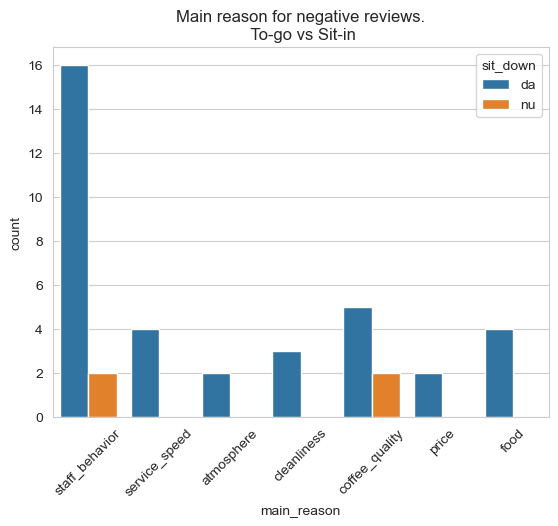

In [191]:
sns.countplot(data=negative, x='main_reason', hue='sit_down')
plt.xticks(rotation=45)
plt.title('Main reason for negative reviews.\n To-go vs Sit-in')

Text(0.5, 1.0, 'Main reason for positive reviews.\n To-go vs Sit-in')

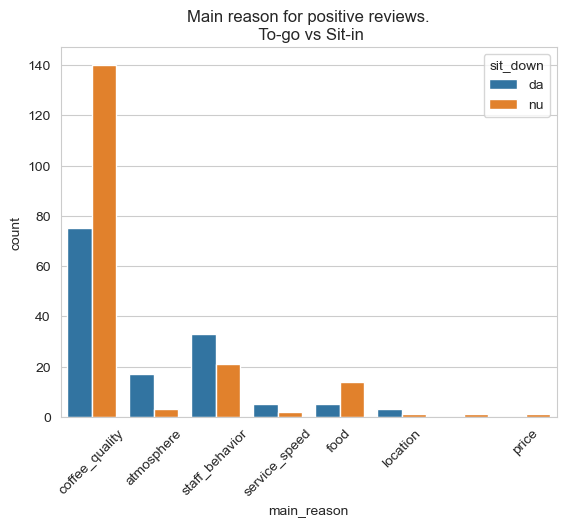

In [192]:
sns.countplot(data=positive, x='main_reason', hue='sit_down')
plt.xticks(rotation=45)
plt.title('Main reason for positive reviews.\n To-go vs Sit-in')

### 9.2 Topics comparison

In [131]:
topics_by_sitdown = data_by_sitdown['topics'].value_counts()

In [142]:
sit_in_topics = topics_by_sitdown['da'].head(10)

In [151]:
to_go_topics = topics_by_sitdown['nu'].head(10)

### 9.3 Main reason comparison

In [144]:
main_reason_by_sitdown = data_by_sitdown['main_reason'].value_counts()

In [145]:
main_reason_by_sitdown['da'].head()

main_reason
coffee_quality    86
staff_behavior    51
atmosphere        22
service_speed     14
food              13
Name: count, dtype: int64

In [146]:
main_reason_by_sitdown['nu'].head()

main_reason
coffee_quality    147
staff_behavior     25
food               14
                    4
atmosphere          3
Name: count, dtype: int64

In [150]:
data.groupby(['sit_down','main_reason']).size().sort_values(ascending=False)

sit_down  main_reason   
nu        coffee_quality    147
da        coffee_quality     86
          staff_behavior     51
nu        staff_behavior     25
da        atmosphere         22
          service_speed      14
nu        food               14
da        food               13
          location            4
          price               4
nu                            4
          atmosphere          3
da        cleanliness         3
nu        service_speed       3
da                            3
nu        location            2
          price               2
dtype: int64

Text(0.5, 1.0, 'Main Reasons Mentioned in Reviews: Sit-down vs To-go')

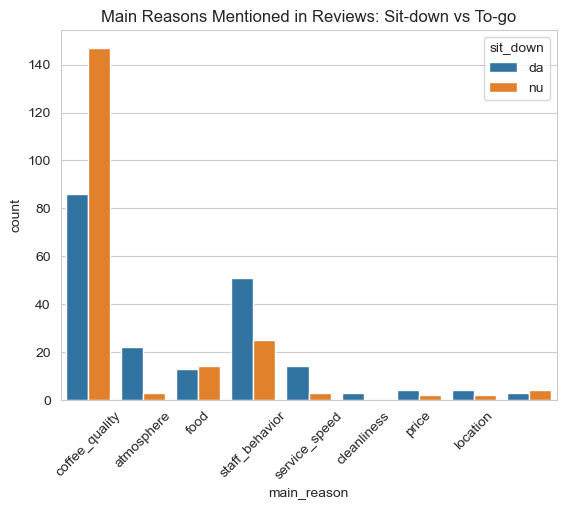

In [164]:
sns.countplot(data=data, x='main_reason', hue='sit_down')

plt.xticks(rotation=45)
plt.title("Main Reasons Mentioned in Reviews: Sit-down vs To-go")


In [154]:
top_reasons = data['main_reason'].value_counts().head(5).index

In [156]:
filtered = data[data['main_reason'].isin(top_reasons)]

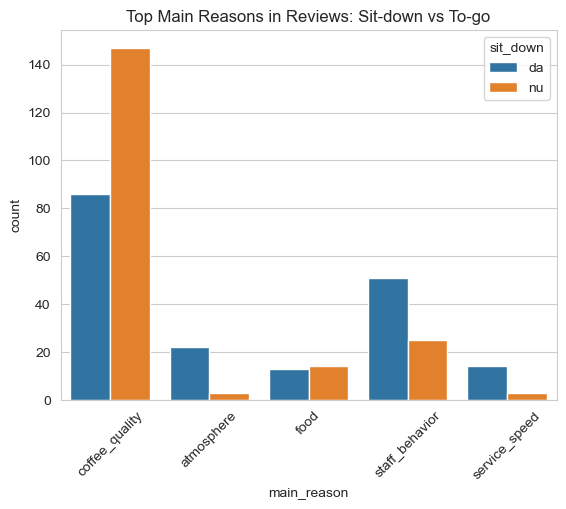

In [162]:
sns.set_style('whitegrid')
sns.countplot(data=filtered, x='main_reason', hue='sit_down')

plt.xticks(rotation=45)
plt.title("Top Main Reasons in Reviews: Sit-down vs To-go")
plt.show()

#    10. Final insights

## 10.1 Overall Customer Experience Insights
#### Customer Experience Drivers
The analysis shows that coffee quality is by far the most frequently mentioned factor in customer reviews, appearing in 233 cases as the main reason.
This suggests that the core product remains the most important determinant of customer satisfaction in cafes. Regardless of service or atmosphere, customers primarily evaluate their experience based on the quality of the coffee itself.
The second most common reason mentioned in reviews is staff behavior (76 mentions).
This indicates that customer interaction plays a significant role in shaping the overall experience. Even when coffee quality is good, negative staff interactions can still lead to dissatisfaction.
### Insights from Negative Reviews
The analysis shows that staff behavior is the most common reason behind negative reviews, appearing 18 times as the main reason. It appears in topic combinations as well. Negative reviews frequently mention several issues at the same time, such as: staff behavior + coffee quality, staff behavior + service speed, coffee quality + food + price.
This suggests that customer interaction plays a critical role in shaping the overall perception of the café. Even when the product itself is acceptable, poor staff behavior can strongly impact customer satisfaction.

## 10.2 Comparative Insights: To-Go vs Sit-Down Cafes
### Rating differences between To-Go and Sit-In Cafes.
The analysis shows that to-go cafés tend to have slightly higher average ratings than sit-down cafés.
This difference may be explained by the type of customer expectations and interaction involved in each experience. At to go cafes, because the interaction is short and focused on the product itself, there are fewer factors that can negatively influence the experience.
In contrast, sit-down cafés involve a more complex customer experience. Since more aspects are involved, there are more opportunities for dissatisfaction, which can lead to lower ratings.
### Differences Between Cafe Types in sentiments and main reason
The analysis highlights clear differences in what drives customer satisfaction depending on the café format. Coffee quality stands out as the main driver of positive reviews in both sit-down and to-go cafes, confirming that the core product remains the foundation of customer satisfaction regardless of context. However, sit-down cafes appear significantly more sensitive to staff behavior, which represents the dominant source of negative reviews, suggesting that longer visits increase the importance of customer–staff interaction. In contrast, to-go cafes generate far fewer complaints and are mainly evaluated based on product quality and efficiency, likely because shorter, transactional visits reduce exposure to service-related issues. Sit-down locations receive feedback across a wider range of factors, including atmosphere, food, service speed, and cleanliness, indicating that customers perceive them as a complete experience rather than a simple purchase. This broader experience creates both more opportunities to impress and a higher risk of dissatisfaction. Overall, the findings suggest that customer satisfaction is strongly context-dependent: to-go cafes are judged primarily on functional efficiency and product consistency, while sit-down cafes are evaluated through a more complex experiential lens where service quality and environment play a crucial role.

## 10.3 Strategic Recommendations

Based on the analysis, several strategic priorities emerge for improving customer satisfaction and overall performance.

### For All Cafes:

    -Maintain consistent coffee quality through standardized preparation procedures and ingredient quality control
    -Monitor customer feedback regularly to identify emerging service or product issues
    -Implement clear service standards to ensure a predictable and reliable customer experience

### For Sit-Down Cafes:
    -Invest in staff training and customer interaction skills, as service behavior strongly influences negative experiences
    -Enhance atmosphere and comfort to strengthen the experiential value customers expect
    -Improve operational consistency across food quality, cleanliness, and service flow

### For To-Go Cafes:

    -Optimize service speed and efficiency to meet transactional customer expectations
    -Ensure order accuracy and workflow optimization during peak hours
    -Preserve product consistency as the primary driver of positive feedback